## 46-881 Class 7

## ML with Python: A Tour of scikit-learn

Amr Farahat

CMU / Tepper

2022-12-12

---

The models below illustrate the basic modeling functionality of Python's scikit-learn - a widely-used machine learning package. Think of this notebook as a quick tour or preview of the package.

We will not go over the details of the algorithms or their underlying theory - this is covered in other courses (e.g. 46-886 "Machine Learning Fundamentals", for which 45-886, or equivalent, is a pre-requisite). In general, you should wait until you fully understand an algorithm before using it.

Also, I will not attempt to tune the model hyper-paramaters. I will largely stick to the defaults (or, in the case of trees, to simple models). Thus the models may be under- or over- fitting the data. (Again, I cover how to handle that issue properly in 46-886).

If you are eager to start learning the underlying theory on your own then I suggest the "Introduction to Statistical Learning" second version (ISLR2), available online here:
https://www.statlearning.com/

Alas ISLRs uses R, but you can combine the exposition of methods with scikit's reference manual:
https://scikit-learn.org

---

## 0. Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
pd.options.display.max_columns = None

## 1. Regression Application: Bike Rentals
**Predicting number of bike rentals in the Pittsburgh rideshare system at the hourly level in terms of temporal and weather variables**

### 1.0. Reading in and pre-processing data

In [3]:
df = pd.read_csv("PIT_bike_rentals.csv")

In [4]:
df = df.drop("day", axis=1)  # not relevant

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8759 entries, 0 to 8758
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rentals        8759 non-null   int64  
 1   month          8759 non-null   int64  
 2   hour           8759 non-null   int64  
 3   day_of_week    8759 non-null   object 
 4   temperature    8750 non-null   float64
 5   humidity       8750 non-null   float64
 6   windspeed      8687 non-null   float64
 7   precipitation  8746 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 547.6+ KB


In [6]:
df_c = df.dropna(axis = 0, how = 'any')

In [7]:
categorical_vars = ["month", "hour", "day_of_week"] 

In [8]:
df_cc = pd.get_dummies(df_c, columns = categorical_vars, drop_first=True)

In [9]:
target = df_cc["rentals"]

In [10]:
features = df_cc.drop("rentals", axis=1)

In [11]:
y = target.values
X = features.values

#### Train / Test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=881)

### 1.1. Linear Regression Model

In [13]:
mod_lr = LinearRegression()
mod_lr.fit(X_train, y_train)

LinearRegression()

In [14]:
mod_lr.intercept_

4.895971832993011

In [15]:
mod_lr.coef_

array([ 0.39427863, -0.22854716, -0.2193233 , -6.45456387,  0.35289148,
       -0.79098094,  0.23391375, -0.89731741, -0.97601715, -0.65226852,
       -1.55770514,  4.96648827,  3.88247119, -0.17647278, -3.63834471,
       -2.25336009, -1.91028954, -3.01313544, -3.74523563, -3.19247216,
       -2.18128859, -1.85179307,  0.32082555,  2.28206464,  2.80108755,
        3.7680221 ,  6.19421407,  8.23631805,  8.87554413, 11.09625448,
       13.43511889, 14.6590006 , 15.36010426, 13.74126595, 11.1129017 ,
        7.53169608,  3.88047516,  1.85756446, -1.21481589,  5.65978822,
        2.23263317, -1.05905932, -1.02522202, -1.25892372])

In [16]:
print("Linear Regression train R2: ", mod_lr.score(X_train, y_train))
print("Linear Regression test R2: ", mod_lr.score(X_test, y_test))

Linear Regression train R2:  0.6348746996739842
Linear Regression test R2:  0.637799077778791


Note: In computing out-of-sample goodness-of-fit statistics, the baseline (SST) should be based on the train data, not the test data. I'll ignore this technicality here.

### 1.2. Regression Tree Model

In [17]:
mod_reg_tree = DecisionTreeRegressor(max_depth=3)
mod_reg_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

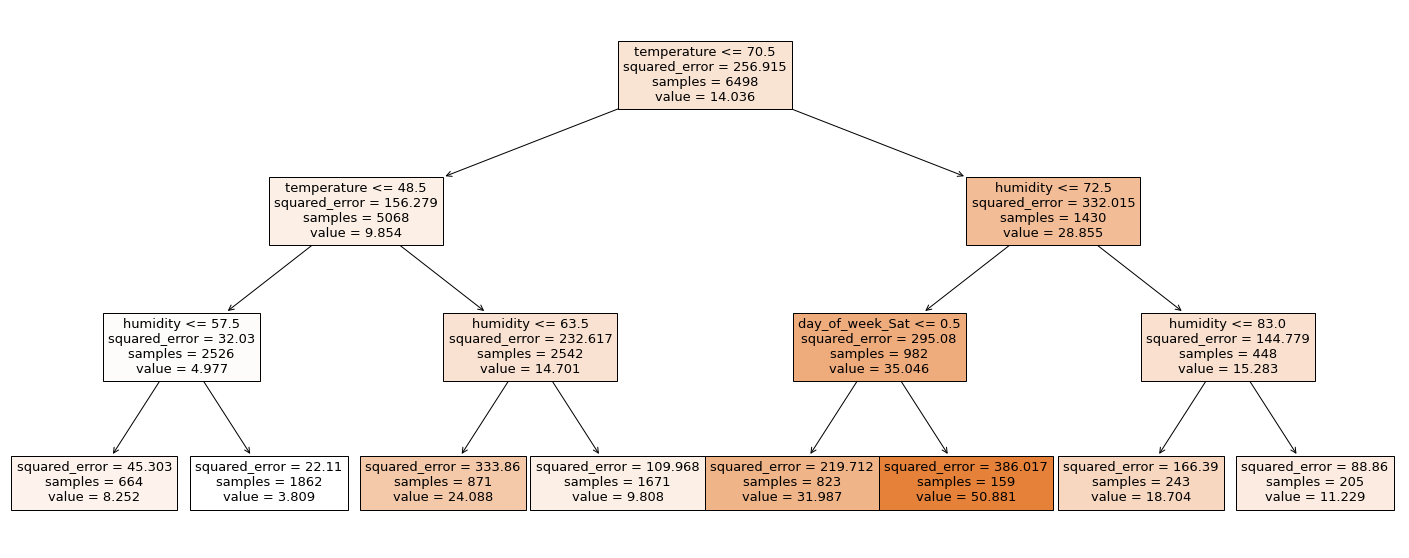

In [18]:
plt.figure(figsize=(25,10))
a = plot_tree(mod_reg_tree, 
              feature_names=list(features.columns),
              filled=True)

In [19]:
print("Regression Tree Train R2: ", mod_reg_tree.score(X_train, y_train))
print("Regression Tree Test R2: ", mod_reg_tree.score(X_test, y_test))

Regression Tree Train R2:  0.49285359744088586
Regression Tree Test R2:  0.4353285521453758


### 1.3. Random Forest Model

In [20]:
mod_reg_rf = RandomForestRegressor(random_state=881)
mod_reg_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=881)

In [21]:
print("Regression Random Forest Train R2: ", mod_reg_rf.score(X_train, y_train))
print("Regression Random Forest Test R2: ", mod_reg_rf.score(X_test, y_test))

Regression Random Forest Train R2:  0.9687299852206642
Regression Random Forest Test R2:  0.7731846561773121


<BarContainer object of 44 artists>

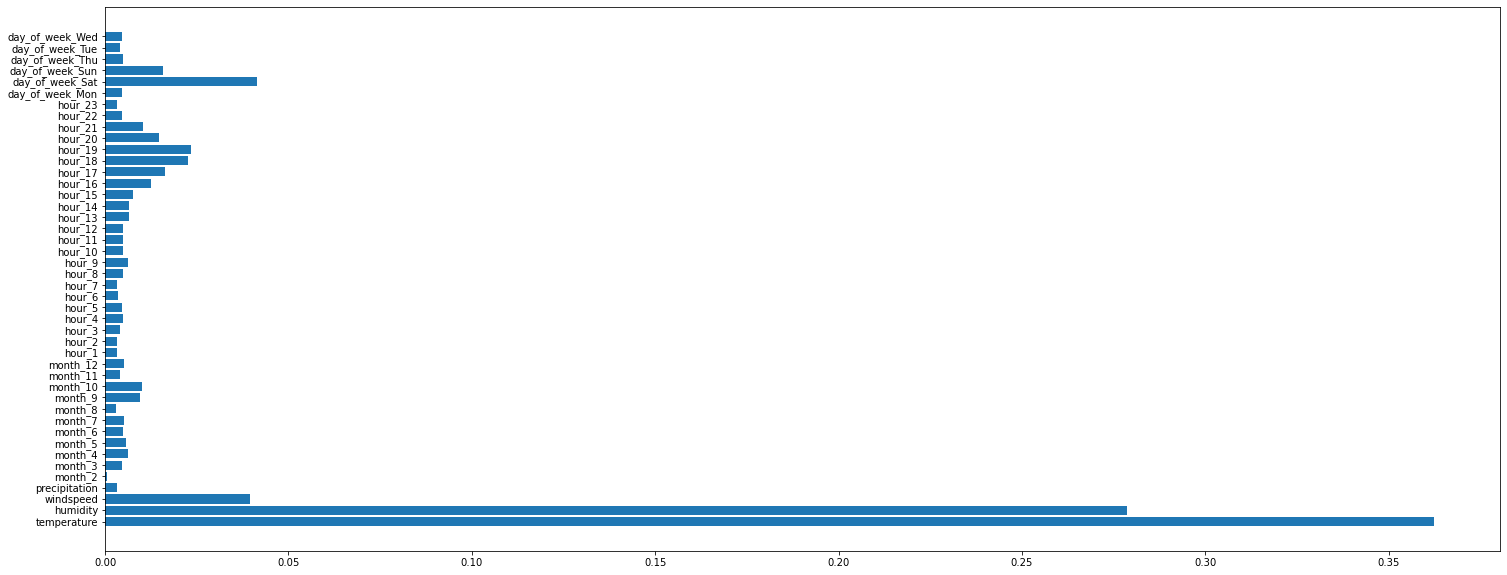

In [22]:
forest_importances = mod_reg_rf.feature_importances_
plt.figure(figsize=(25,10))
plt.barh(features.columns, forest_importances)

### 1.4. Gradient Boosting Model

In [23]:
mod_reg_gb = GradientBoostingRegressor(random_state=881)
mod_reg_gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=881)

In [24]:
print("Regression Gradient Boosting Train R2: ", mod_reg_gb.score(X_train, y_train))
print("Regression Gradient Boosting Test R2: ", mod_reg_gb.score(X_test, y_test))

Regression Gradient Boosting Train R2:  0.7603566722694107
Regression Gradient Boosting Test R2:  0.725801366372727


<BarContainer object of 44 artists>

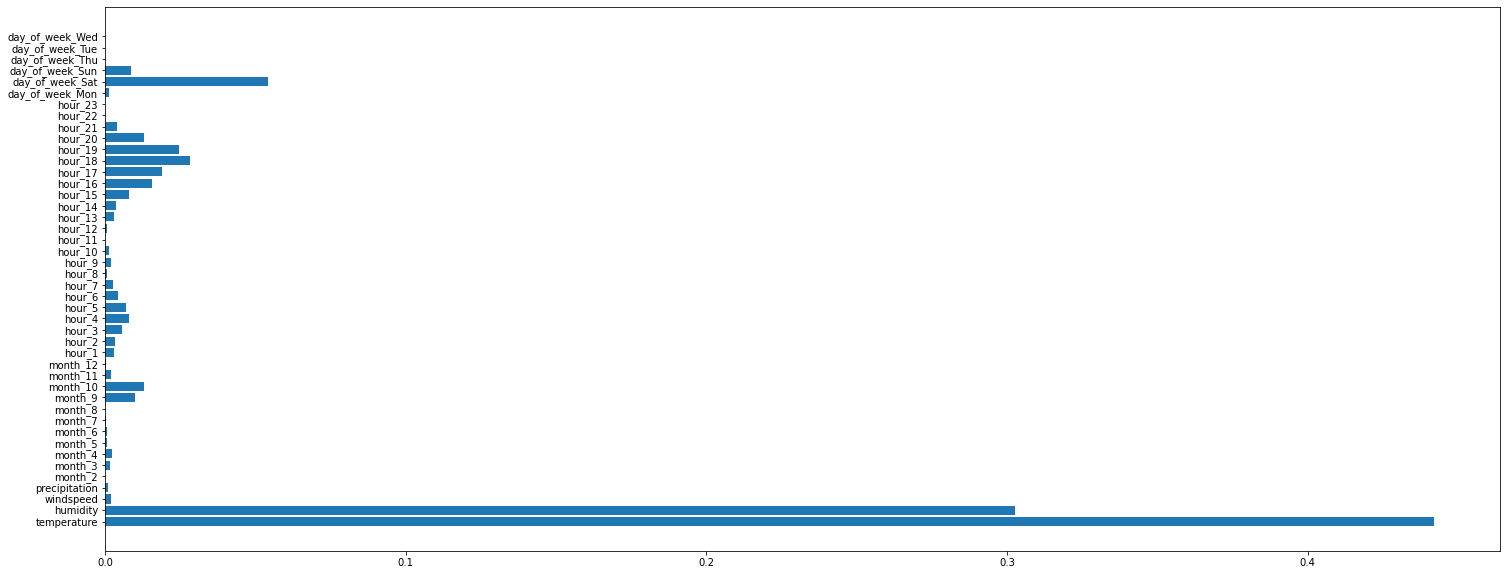

In [25]:
gb_importances = mod_reg_gb.feature_importances_
plt.figure(figsize=(25,10))
plt.barh(features.columns, gb_importances)

## 2. Classification Example: Flight Delays
**Predicting flight depature delays out of PIT**

### 2.0. Reading in and pre-processing data

In [26]:
df = pd.read_csv("PIT_airline_delays.csv")

In [27]:
df = df[["DEP_DEL15", "MONTH", "DAY_OF_WEEK", "OP_CARRIER", "DEST", "DEP_TIME_BLK"]]

In [28]:
df_c = df.dropna(axis = 0, how = 'any')

In [29]:
categorical_vars = ["MONTH", "DAY_OF_WEEK", "OP_CARRIER", "DEST", "DEP_TIME_BLK"] 

In [30]:
df_cc = pd.get_dummies(df_c, columns = categorical_vars, drop_first=True)

In [31]:
target = df_cc["DEP_DEL15"]

In [32]:
features = df_cc.drop("DEP_DEL15", axis=1)

In [33]:
y = target.values
X = features.values

#### Train / Test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=881)

### 2.1. Logistic Regression Model

In [35]:
mod_logr = LogisticRegression()
mod_logr.fit(X_train, y_train)

C:\Users\afarahat\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [36]:
mod_logr.intercept_

array([-3.62851972])

In [37]:
mod_logr.coef_

array([[ 0.15134843,  0.14395494,  0.22168046,  0.26224925,  1.1621667 ,
         1.26989186,  1.29089185,  0.36887133,  0.70695547,  0.44552906,
         0.65278444, -0.34851034, -0.44432747, -0.17797718, -0.09783613,
        -0.07099915, -0.11018026,  0.65045899,  0.15862291,  0.75767554,
        -0.22605798,  0.58040709,  0.98157554,  0.70004316,  0.90682027,
         0.50519953,  0.55949716,  0.01435206,  1.02539269, -0.00739826,
         0.15818279, -0.42665632, -0.21732607, -0.19247271, -0.22924926,
        -0.72942079, -0.08368276, -0.3023947 ,  0.61976886,  0.08761235,
         0.01995409,  0.09044431, -0.08461675,  0.13137709, -0.05083084,
        -0.19890301, -0.39408028, -0.01510989,  0.18067332, -0.64409735,
        -0.20737886, -0.34642674,  0.32696097, -0.11501584, -0.11177799,
        -0.28156577,  0.10668575, -0.83762002, -0.328266  ,  0.30385031,
        -0.31914457,  0.20134155, -0.70267324,  0.28358819, -0.12905382,
        -0.23914918, -0.06883448,  0.03432537,  0.2

In [38]:
print("Logistic Regression Train accuracy: ", mod_logr.score(X_train, y_train))
print("Logistic Regression Test accuracy: ", mod_logr.score(X_test, y_test))

Logistic Regression Train accuracy:  0.8693021713906846
Logistic Regression Test accuracy:  0.8733374766935985


### 2.2. Classification Tree Model

In [39]:
mod_cl_tree = DecisionTreeClassifier(max_depth=3)
mod_cl_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

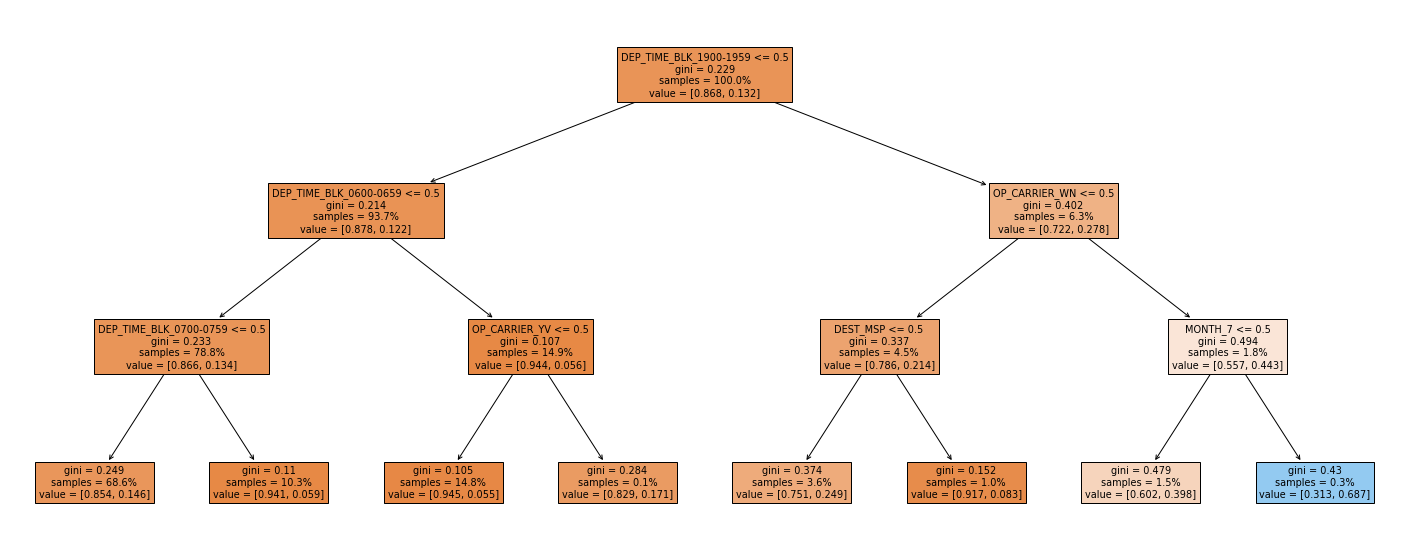

In [40]:
plt.figure(figsize=(25,10))
a = plot_tree(mod_cl_tree, 
              feature_names=list(features.columns),
              filled=True,
              proportion=True)

In [41]:
print("Classification Tree Train R2: ", mod_cl_tree.score(X_train, y_train))
print("Classification Tree Test R2: ", mod_cl_tree.score(X_test, y_test))

Classification Tree Train R2:  0.8692607326371623
Classification Tree Test R2:  0.8727159726538223


### 2.3. Random Forest Model

In [42]:
mod_cl_rf = RandomForestClassifier(random_state=881)
mod_cl_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=881)

In [43]:
print("Classification Random Forest Train R2: ", mod_cl_rf.score(X_train, y_train))
print("Classification Random Forest Test R2: ", mod_cl_rf.score(X_test, y_test))

Classification Random Forest Train R2:  0.908544670976297
Classification Random Forest Test R2:  0.8406463642013673


### 2.4. Gradient Boosting Model

In [44]:
mod_cl_gb = GradientBoostingClassifier(random_state=881)
mod_cl_gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=881)

In [45]:
print("Classification Gradient Boosting Train R2: ", mod_cl_gb.score(X_train, y_train))
print("Classification Gradient Boosting Test R2: ", mod_cl_gb.score(X_test, y_test))

Classification Gradient Boosting Train R2:  0.8714155478203216
Classification Gradient Boosting Test R2:  0.87408328154133


### END